In [1]:
# Листинг 1 – Предобработка данных в Python
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Загрузка данных
df = pd.read_csv("mxmh_survey_results.csv")
df = df.drop(columns=['Timestamp'])
# Кодирование категориальных признаков
cat_columns = df.select_dtypes(include=['object']).columns

# Применяем LabelEncoder к каждому категориальному столбцу
label_encoder = LabelEncoder()
for col in cat_columns:
    df[col] = label_encoder.fit_transform(df[col].astype(str))


numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
# Заполняем пропуски в числовых столбцах средним значением
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].mean())

# Разделение на train/test для классификации
X_class = df.drop(['Music effects', 'Anxiety', 'Depression'], axis=1)
y_class = df['Music effects']
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.3, random_state=42
)

# Разделение на train/test для регрессии
X_reg = df.drop(['Anxiety', 'Depression'], axis=1)
y_reg = df['Anxiety']
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

In [10]:
# Листинг 3 – Логистическая регрессия в Python
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,r2_score,mean_absolute_error

# Обучение модели
logreg = LogisticRegression(max_iter=100000)
logreg.fit(X_train_class, y_train_class)
y_pred_class = logreg.predict(X_test_class)

print("Метрики классификации: ")
# Метрики
acc = accuracy_score(y_test_class, y_pred_class)
cm = confusion_matrix(y_test_class, y_pred_class)
print(f"Accuracy: {acc:.2f}")
print("Confusion Matrix:\n", cm)
# Листинг 5 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Обучение модели
linreg = LinearRegression()
linreg.fit(X_train_reg, y_train_reg)
y_pred_reg = linreg.predict(X_test_reg)

# Метрики
print("Метрики регрессии: ")
mse = mean_squared_error(y_test_reg, y_pred_reg)
print(f"MSE: {mse:.2f}")
r2 = r2_score(y_test_reg, y_pred_reg)
print(f"R2_score: {r2:.2f}")
mae = mean_absolute_error(y_test_reg, y_pred_reg)
print(f"MAE: {mae:.2f}")

Метрики классификации: 
Accuracy: 0.76
Confusion Matrix:
 [[166   1   0]
 [ 51   2   0]
 [  1   0   0]]
Метрики регрессии: 
MSE: 7.24
R2_score: 0.07
MAE: 2.22


In [ ]:
# Листинг 5 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Обучение модели
linreg = LinearRegression()
linreg.fit(X_train_reg, y_train_reg)
y_pred_reg = linreg.predict(X_test_reg)

# Метрики
mse = mean_squared_error(y_test_reg, y_pred_reg)
print(f"MSE: {mse:.2f}")

MSE: 7.24


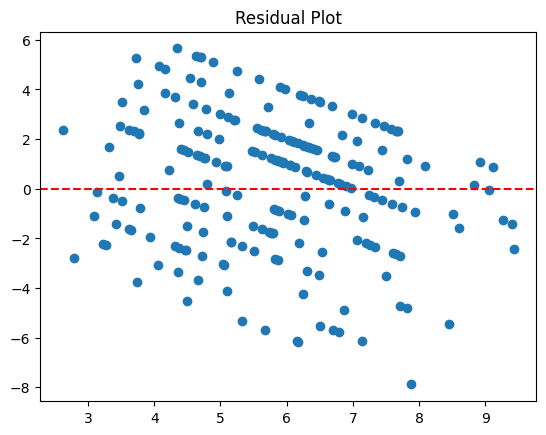

In [6]:
# Листинг 7 – График остатков
import matplotlib.pyplot as plt
residuals = y_test_reg - y_pred_reg
plt.scatter(y_pred_reg, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residual Plot")
plt.show()